# Cs-137 angular scattering-rate analysis

This notebook computes scattering rates for Cs-137 files at different angles for both detector types (`scatter`, `recoil`).

Workflow:
1. Discover angular Cs-137 files
2. Define/edit a per-file peak-index mapping (default `0` for each file)
3. Run a helper function over all files and store results in memory
4. Plot scattering rate vs effective scattering angle

Effective angle definition used:
\[
\theta_{\mathrm{eff}} = 180 - |\,\theta - 180\,|
\]

In [106]:
from pathlib import Path
import re

import numpy as np
import matplotlib.pyplot as plt

from analysis_evan import (
    read_spe,
    find_peak_candidates,
    fit_local_peak,
    peak_rate_from_fit,
    gaussian_plus_linear,
)

plt.rcParams["figure.figsize"] = (7.5, 4.8)
plt.rcParams["axes.grid"] = False
plt.rcParams["axes.labelsize"] = 16
plt.rcParams["xtick.labelsize"] = 14
plt.rcParams["ytick.labelsize"] = 14
plt.rcParams["legend.fontsize"] = 14


def parse_cs137_angular_filename(filename):
    """
    Parse names like:
      03-05-Cs137-recoil-280.Spe
      03-10-Cs137-Scatter-205.Spe
      03-12-Cs137-scatter-50.Spe

    Returns dict with date, detector_type, angle_deg.
    """
    m = re.match(
        r"^(?P<date>\d{2}-\d{2})-Cs-?137-(?P<det>scatter|recoil)-(?P<angle>-?\d+(?:\.\d+)?)\.Spe$",
        filename,
        flags=re.IGNORECASE,
    )
    if not m:
        raise ValueError(f"Filename not recognized as angular Cs-137 file: {filename}")

    return {
        "date": m.group("date"),
        "detector_type": m.group("det").lower(),
        "angle_deg": float(m.group("angle")),
    }


def effective_scattering_angle(angle_deg):
    return 180.0 - abs(angle_deg - 180.0)


def analyze_angular_file(
    filename,
    *,
    peak_index_map,
    data_dir="data",
    rebin_factor=8 ,
    min_bin=40,
    prominence=None,
    height=None,
    distance=20,
    max_peaks=10,
    fit_half_width=20,
    min_p_value=0.0,
    plot_pad_bins=8,
    show_plots=False,
):
    """
    Analyze one angular Cs-137 file and return fitted rate info.

    peak_index_map: dict {filename: candidate_index}
    """
    meta = parse_cs137_angular_filename(filename)

    notebook_dir = Path.cwd()
    spe_path = notebook_dir / data_dir / filename
    sp = read_spe(str(spe_path), rebin_factor=rebin_factor)

    cands = find_peak_candidates(
        sp.bins,
        sp.counts,
        min_bin=min_bin,
        prominence=prominence,
        height=height,
        distance=distance,
        max_peaks=max_peaks,
    )
    if len(cands.candidate_bins) == 0:
        raise ValueError(f"No candidate peaks found for {filename}")

    candidate_idx = int(peak_index_map.get(filename, 0))
    if candidate_idx < 0 or candidate_idx >= len(cands.candidate_bins):
        raise ValueError(
            f"Candidate index {candidate_idx} out of range for {filename}; "
            f"found {len(cands.candidate_bins)} candidates"
        )

    candidate_bin = float(cands.candidate_bins[candidate_idx])
    fit = fit_local_peak(
        sp.bins,
        sp.counts,
        candidate_bin=candidate_bin,
        fit_half_width=fit_half_width,
        min_p_value=min_p_value,
    )

    rate_cps, rate_err_cps = peak_rate_from_fit(
        fit,
        live_time_s=sp.live_time_s,
        method="gaussian_area",
    )

    if show_plots:
        print("=" * 90)
        print(
            f"{filename} | detector={meta['detector_type']} | "
            f"angle={meta['angle_deg']:.1f} deg | theta_eff={effective_scattering_angle(meta['angle_deg']):.1f} deg"
        )
        print(f"selected candidate index = {candidate_idx}")

        # Fit model over local fit window
        left, right = fit.fit_range
        xfit = sp.bins[left:right + 1]
        yfit = sp.counts[left:right + 1]
        xdense = np.linspace(xfit.min(), xfit.max(), 500)
        ydense = gaussian_plus_linear(
            xdense,
            fit.amplitude,
            fit.fit_center,
            fit.sigma,
            fit.background_intercept,
            fit.background_slope,
        )

        stats_text = (
            rf"$\chi^2/\mathrm{{ndof}}$ = {fit.chi2_val:.2f}/{fit.ndof}" + "\n"
            + rf"$p$ = {fit.p_value:.4f}"
        )

        # Full spectrum plot
        plt.figure()
        plt.bar(sp.bins, sp.counts, width=1.0, color="#4C78A8")
        plt.xlabel("Bin")
        plt.ylabel("Counts")
        plt.tight_layout()
        plt.show()

        # Local zoomed fit plot
        plot_left = max(0, left - plot_pad_bins)
        plot_right = min(len(sp.bins) - 1, right + plot_pad_bins)
        xplot = sp.bins[plot_left:plot_right + 1]
        yplot = sp.counts[plot_left:plot_right + 1]

        plt.figure()
        plt.bar(xplot, yplot, width=1.0, color="#4C78A8", label="Data")
        plt.plot(xdense, ydense, color="#E45756", lw=2.5, label="Gaussian + linear fit")
        plt.axvline(fit.fit_center, color="#54A24B", ls="--", lw=2, label=f"mu = {fit.fit_center:.2f}")
        plt.xlabel("Bin")
        plt.ylabel("Counts")
        plt.legend()
        plt.text(
            0.98,
            0.98,
            stats_text,
            transform=plt.gca().transAxes,
            ha="right",
            va="top",
            fontsize=14,
            bbox=dict(boxstyle="round", facecolor="white", edgecolor="black", alpha=0.8),
        )
        plt.tight_layout()
        plt.show()

    return {
        "filename": filename,
        "date": meta["date"],
        "detector_type": meta["detector_type"],
        "angle_deg": meta["angle_deg"],
        "theta_eff_deg": effective_scattering_angle(meta["angle_deg"]),
        "candidate_idx": candidate_idx,
        "candidate_bin": candidate_bin,
        "fit_center": fit.fit_center,
        "fit_center_err": fit.fit_center_err,
        "sigma": fit.sigma,
        "sigma_err": fit.sigma_err,
        "chi2": fit.chi2_val,
        "ndof": fit.ndof,
        "p_value": fit.p_value,
        "live_time_s": sp.live_time_s,
        "rate_cps": rate_cps,
        "rate_err_cps": rate_err_cps,
    }

In [107]:
# Discover all angular Cs-137 files and create default peak-index mapping
all_spe_files = sorted([p.name for p in (Path.cwd() / "data").glob("*.Spe")])

cs137_angular_files = []
for fn in all_spe_files:
    try:
        _ = parse_cs137_angular_filename(fn)
        cs137_angular_files.append(fn)
    except ValueError:
        pass

print(f"Found {len(cs137_angular_files)} angular Cs-137 files")
for i, fn in enumerate(cs137_angular_files):
    print(f"  [{i:02d}] {fn}")

# Peak indices in the same order as cs137_angular_files
selected_peak_indices = [2, 1, 3, 4, 4, 4, 4, 3, 3, 1, 0, 0, 0, 1, 1, 5, 0, 2, 4, 2]

if len(selected_peak_indices) != len(cs137_angular_files):
    raise ValueError(
        f"Length mismatch: got {len(selected_peak_indices)} indices for "
        f"{len(cs137_angular_files)} files"
    )

peak_index_map = dict(zip(cs137_angular_files, selected_peak_indices))

print("\npeak_index_map loaded from provided ordered index list:")
for i, fn in enumerate(cs137_angular_files):
    print(f"  [{i:02d}] {fn} -> {peak_index_map[fn]}")

Found 20 angular Cs-137 files
  [00] 03-05-Cs137-recoil-280.Spe
  [01] 03-05-Cs137-scatter-280.Spe
  [02] 03-10-Cs137-Recoil-205.Spe
  [03] 03-10-Cs137-Recoil-210.Spe
  [04] 03-10-Cs137-Recoil-215.Spe
  [05] 03-10-Cs137-Recoil-220.Spe
  [06] 03-10-Cs137-Recoil-225.Spe
  [07] 03-10-Cs137-Recoil-250.Spe
  [08] 03-10-Cs137-Recoil-310.Spe
  [09] 03-10-Cs137-Scatter-205.Spe
  [10] 03-10-Cs137-Scatter-210.Spe
  [11] 03-10-Cs137-Scatter-215.Spe
  [12] 03-10-Cs137-Scatter-220.Spe
  [13] 03-10-Cs137-Scatter-225.Spe
  [14] 03-10-Cs137-Scatter-250.Spe
  [15] 03-10-Cs137-Scatter-310.Spe
  [16] 03-12-Cs137-recoil-50.Spe
  [17] 03-12-Cs137-recoil-80.Spe
  [18] 03-12-Cs137-scatter-50.Spe
  [19] 03-12-Cs137-scatter-80.Spe

peak_index_map loaded from provided ordered index list:
  [00] 03-05-Cs137-recoil-280.Spe -> 2
  [01] 03-05-Cs137-scatter-280.Spe -> 1
  [02] 03-10-Cs137-Recoil-205.Spe -> 3
  [03] 03-10-Cs137-Recoil-210.Spe -> 4
  [04] 03-10-Cs137-Recoil-215.Spe -> 4
  [05] 03-10-Cs137-Recoil-220.S

03-05-Cs137-recoil-280.Spe | detector=recoil | angle=280.0 deg | theta_eff=80.0 deg
selected candidate index = 2


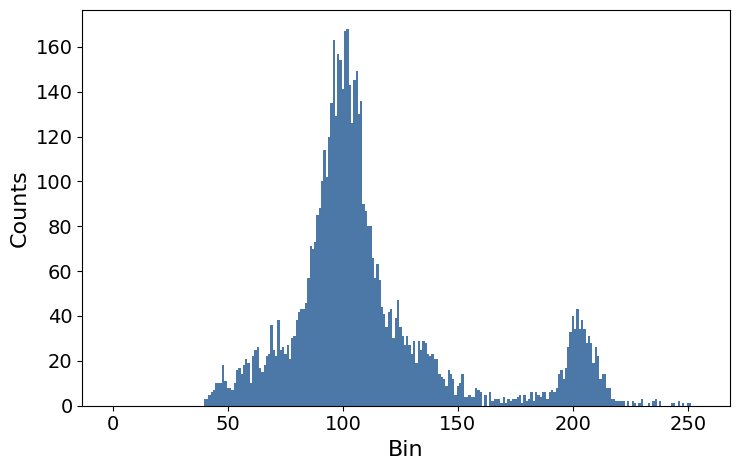

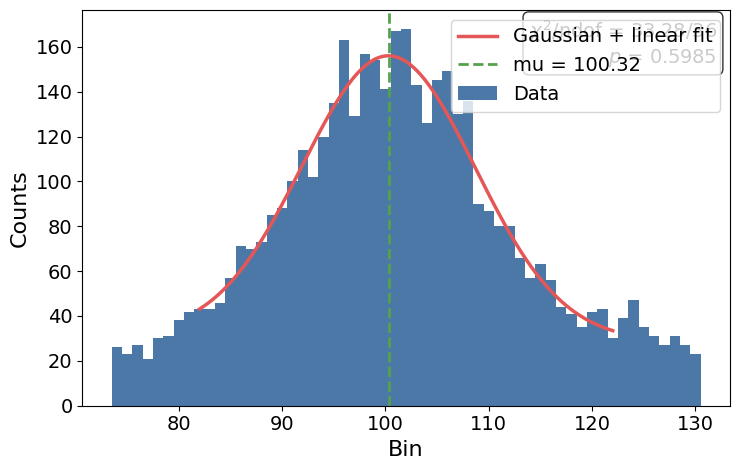

03-05-Cs137-scatter-280.Spe | detector=scatter | angle=280.0 deg | theta_eff=80.0 deg
selected candidate index = 1


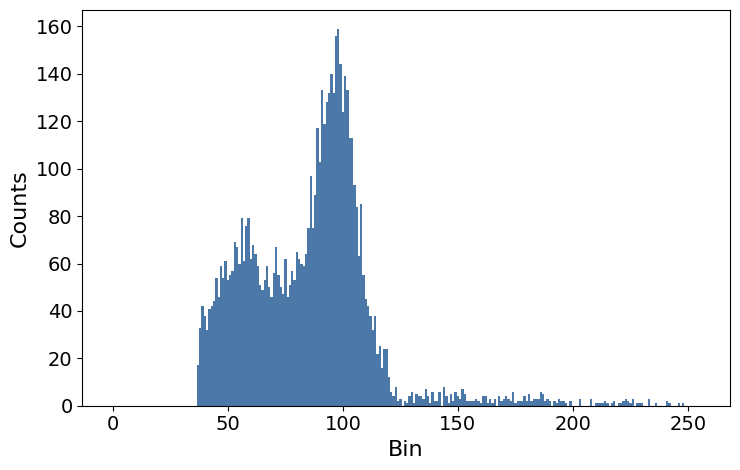

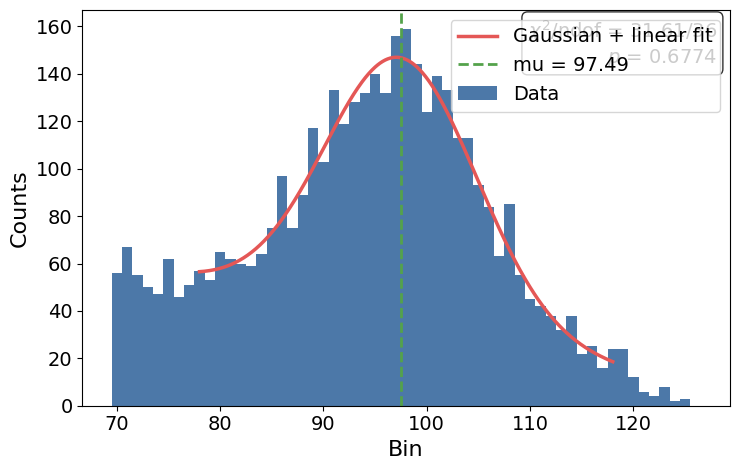

03-10-Cs137-Recoil-205.Spe | detector=recoil | angle=205.0 deg | theta_eff=155.0 deg
selected candidate index = 3


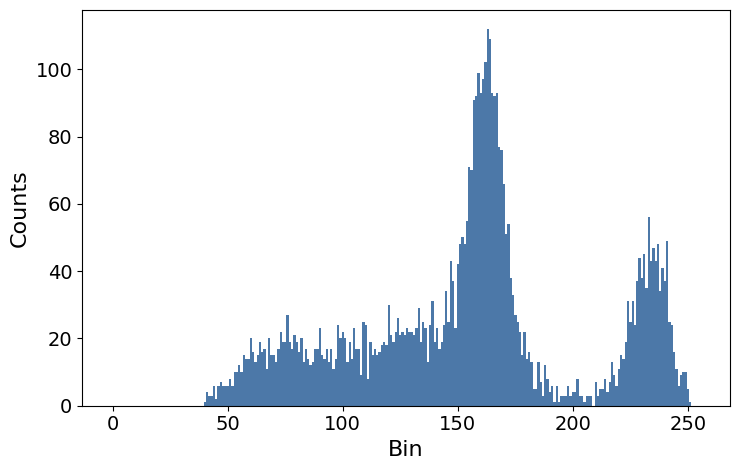

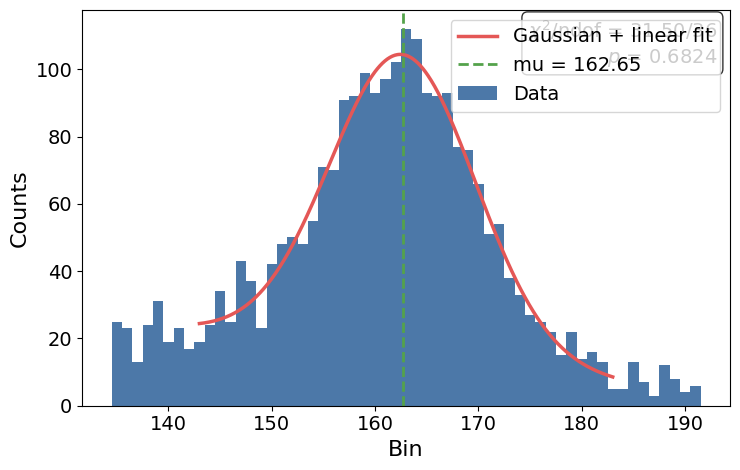

03-10-Cs137-Recoil-210.Spe | detector=recoil | angle=210.0 deg | theta_eff=150.0 deg
selected candidate index = 4


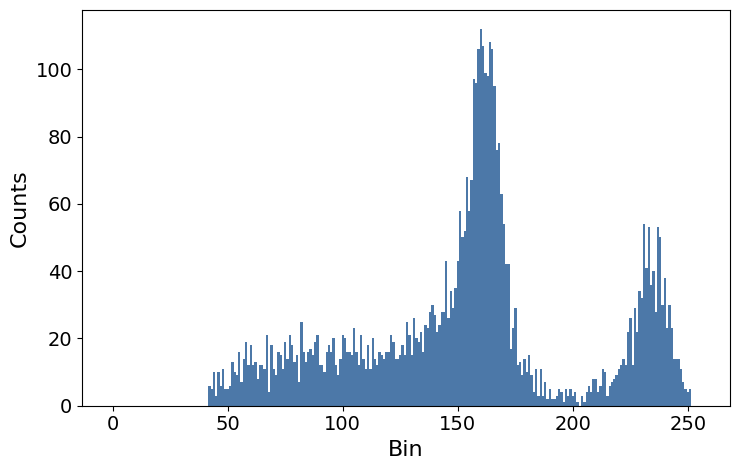

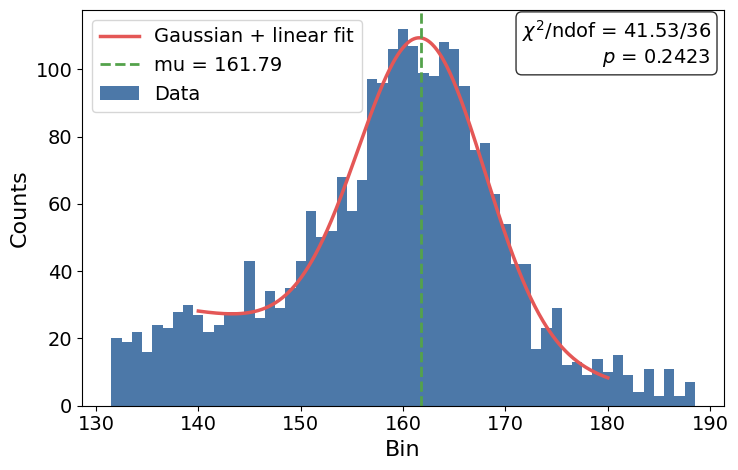

03-10-Cs137-Recoil-215.Spe | detector=recoil | angle=215.0 deg | theta_eff=145.0 deg
selected candidate index = 4


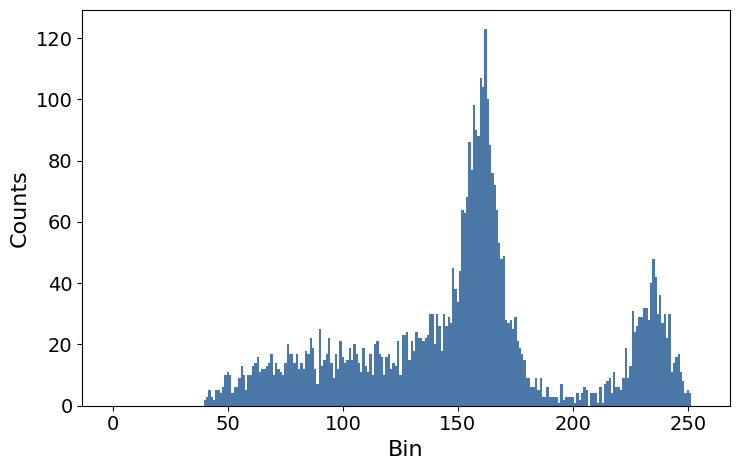

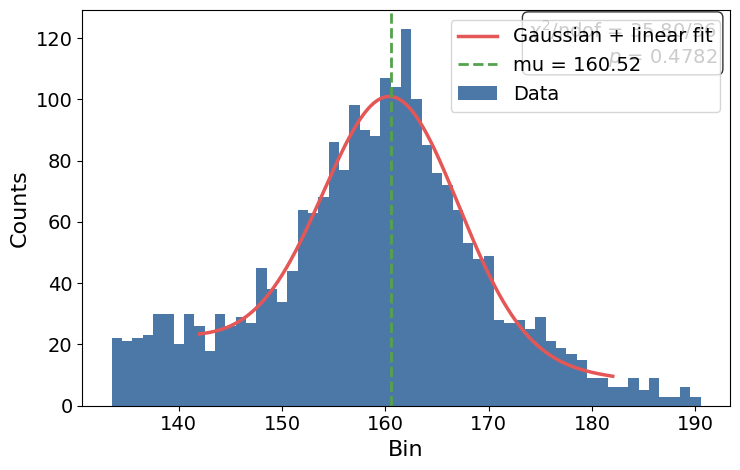

03-10-Cs137-Recoil-220.Spe | detector=recoil | angle=220.0 deg | theta_eff=140.0 deg
selected candidate index = 4


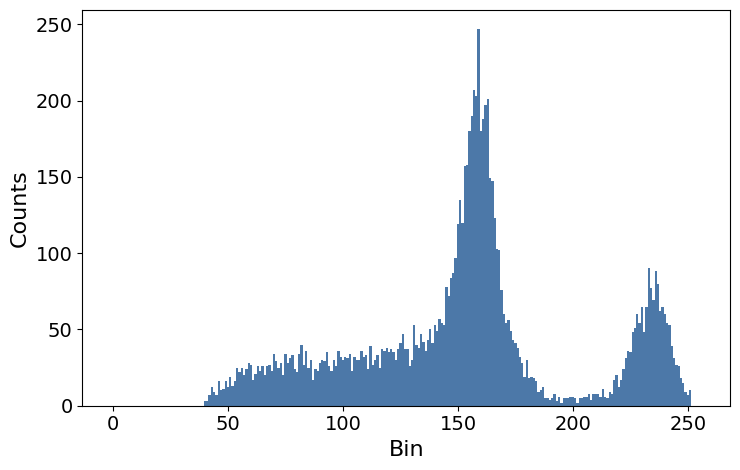

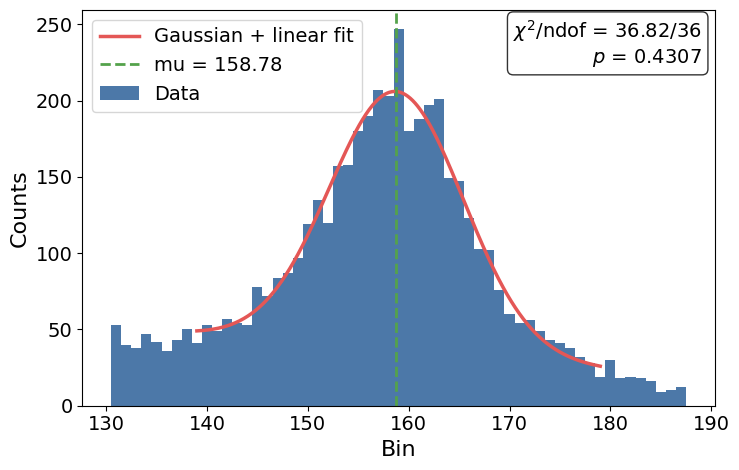

03-10-Cs137-Recoil-225.Spe | detector=recoil | angle=225.0 deg | theta_eff=135.0 deg
selected candidate index = 4


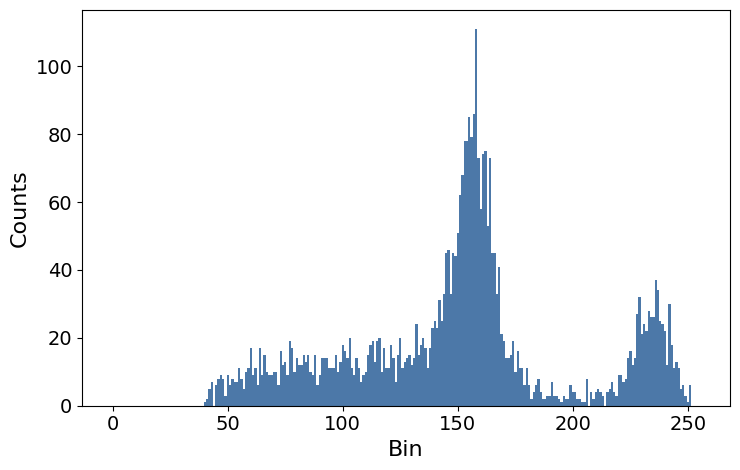

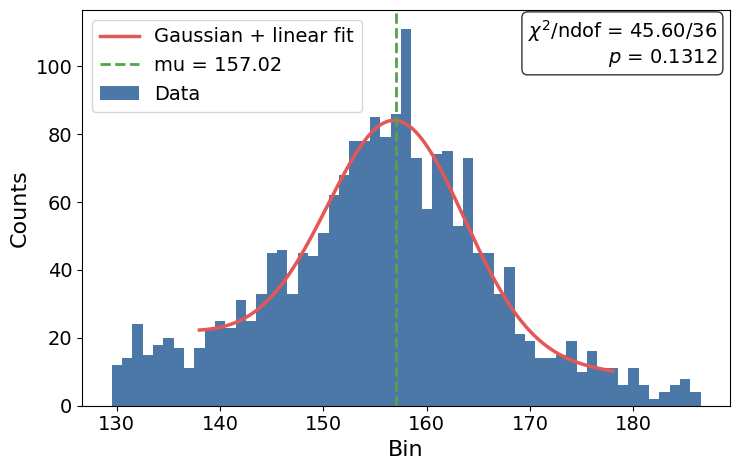

03-10-Cs137-Recoil-250.Spe | detector=recoil | angle=250.0 deg | theta_eff=110.0 deg
selected candidate index = 3


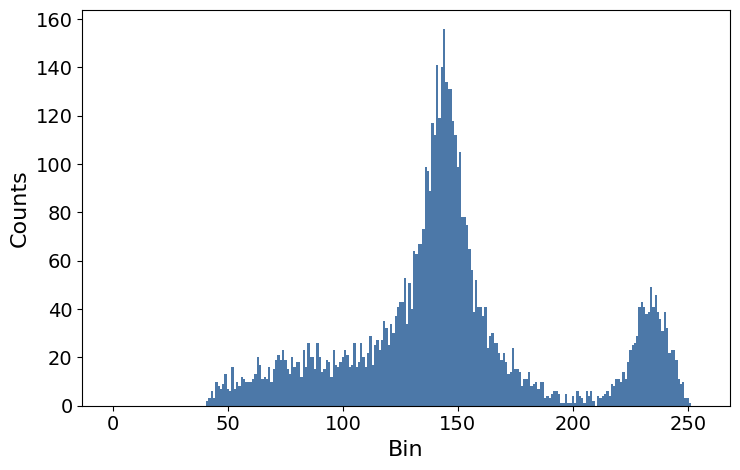

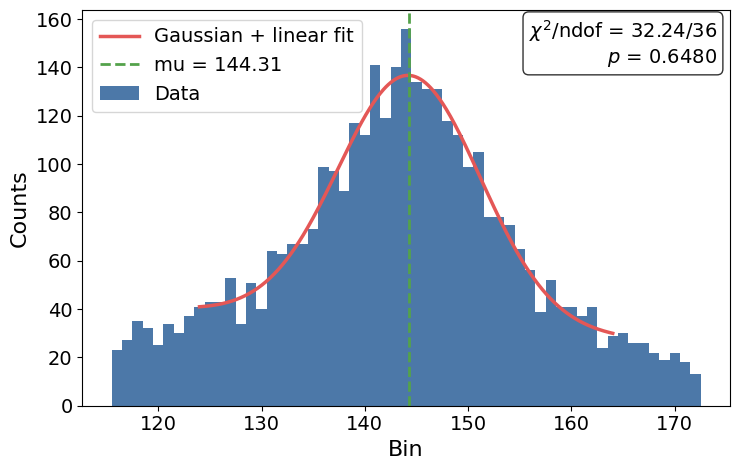

[SKIP] 03-10-Cs137-Recoil-310.Spe (angle = 310 deg)
03-10-Cs137-Scatter-205.Spe | detector=scatter | angle=205.0 deg | theta_eff=155.0 deg
selected candidate index = 1


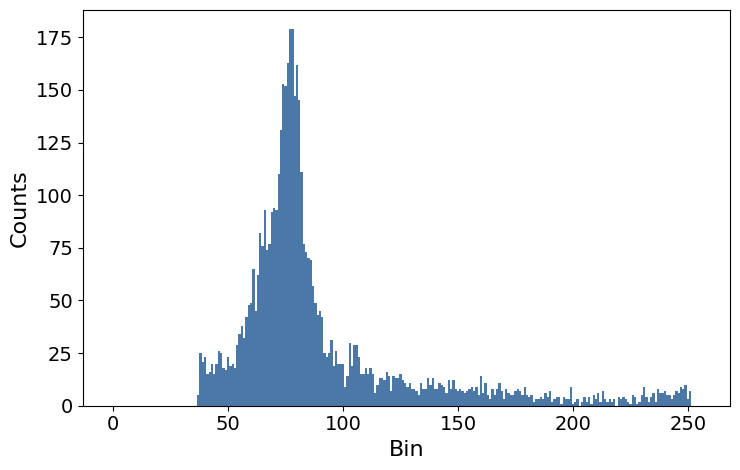

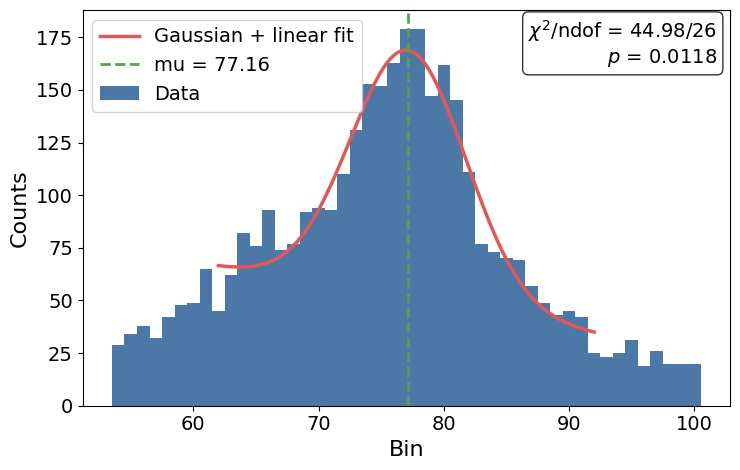

03-10-Cs137-Scatter-210.Spe | detector=scatter | angle=210.0 deg | theta_eff=150.0 deg
selected candidate index = 0


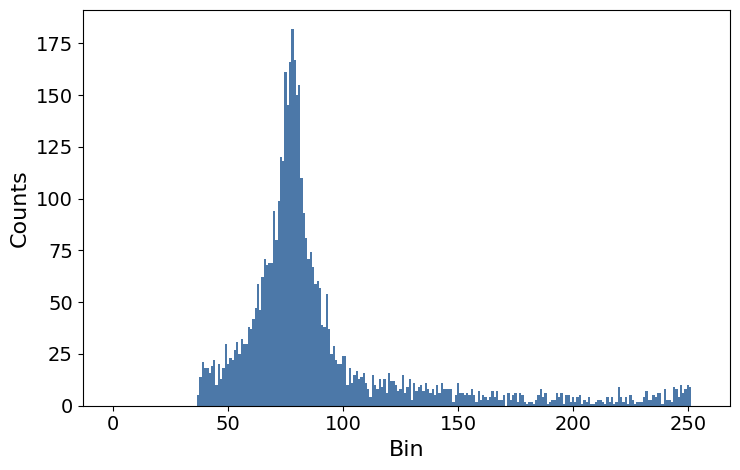

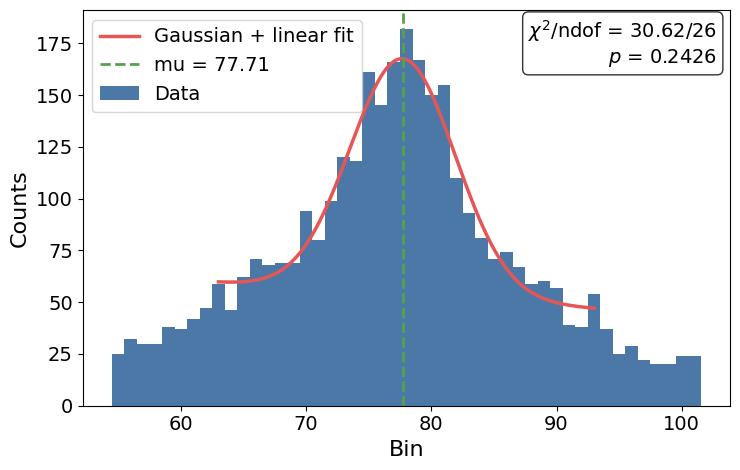

03-10-Cs137-Scatter-215.Spe | detector=scatter | angle=215.0 deg | theta_eff=145.0 deg
selected candidate index = 0


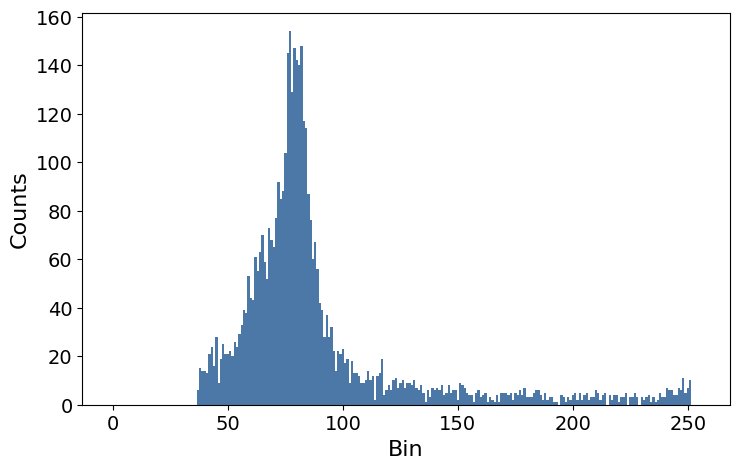

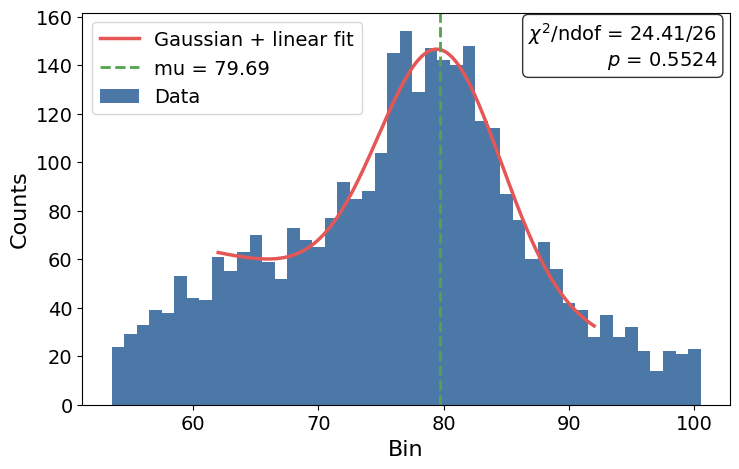

03-10-Cs137-Scatter-220.Spe | detector=scatter | angle=220.0 deg | theta_eff=140.0 deg
selected candidate index = 0


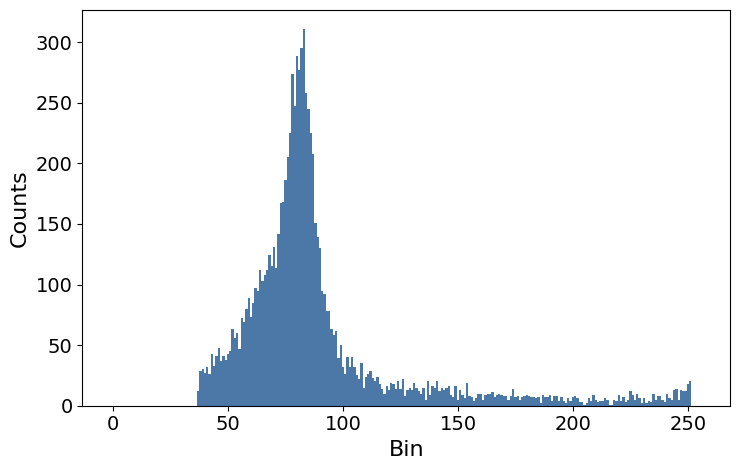

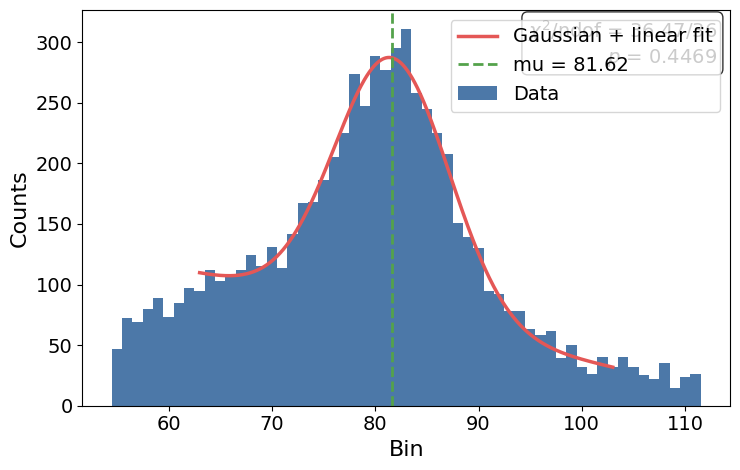

03-10-Cs137-Scatter-225.Spe | detector=scatter | angle=225.0 deg | theta_eff=135.0 deg
selected candidate index = 1


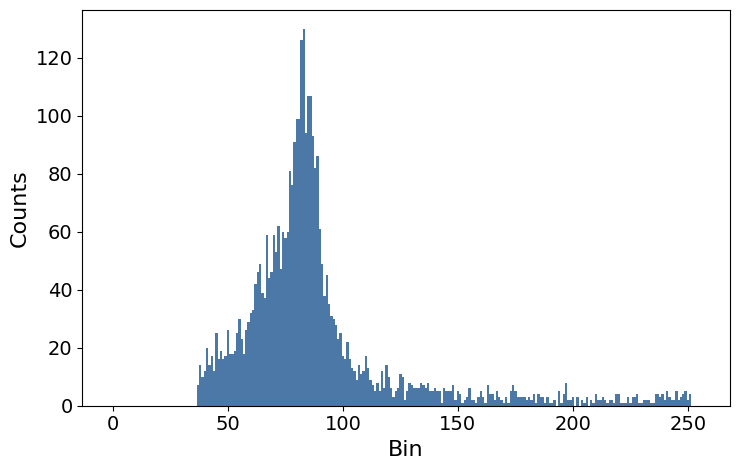

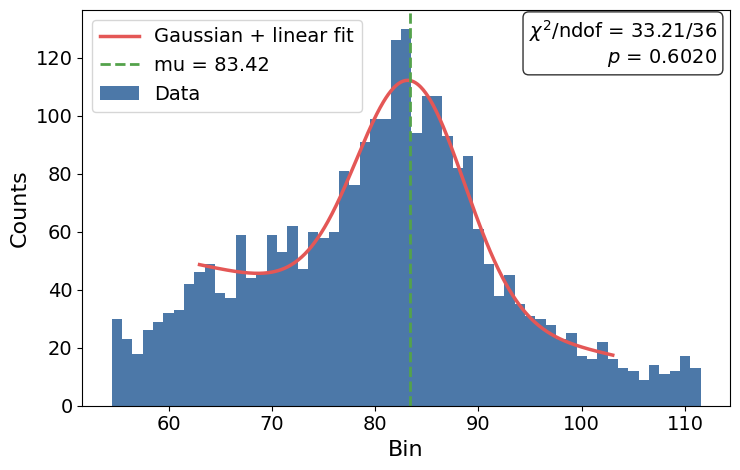

03-10-Cs137-Scatter-250.Spe | detector=scatter | angle=250.0 deg | theta_eff=110.0 deg
selected candidate index = 1


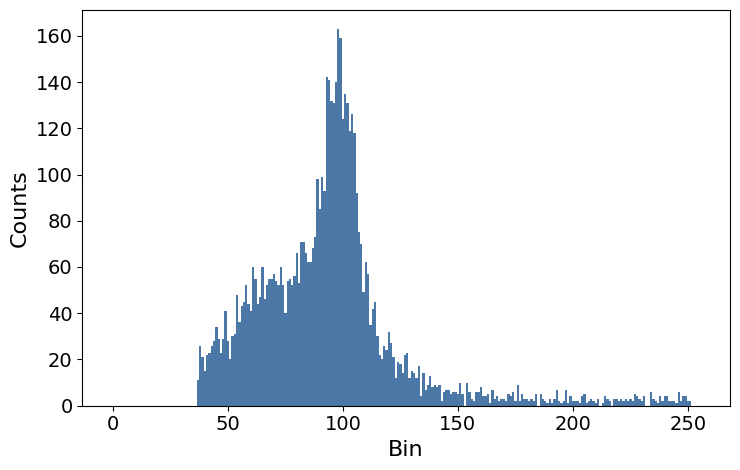

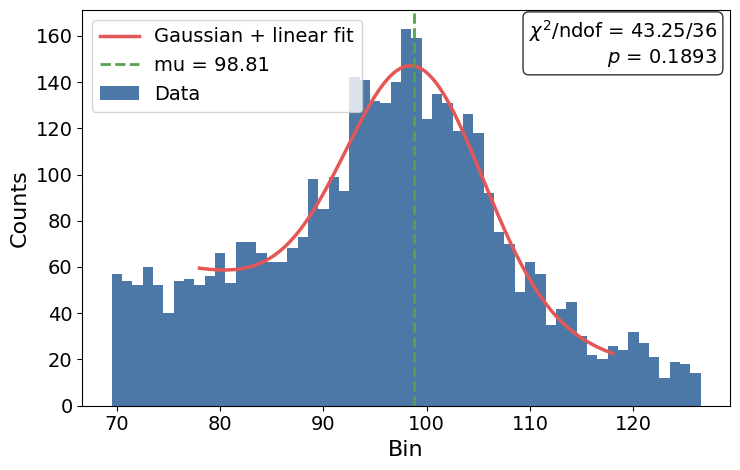

[SKIP] 03-10-Cs137-Scatter-310.Spe (angle = 310 deg)
03-12-Cs137-recoil-50.Spe | detector=recoil | angle=50.0 deg | theta_eff=50.0 deg
selected candidate index = 0


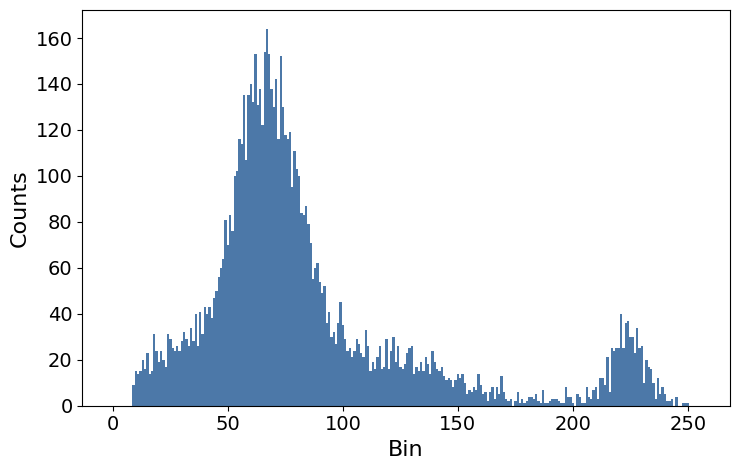

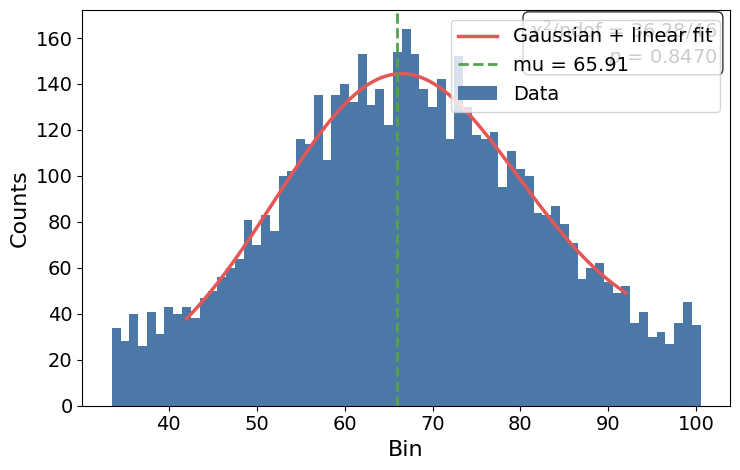

03-12-Cs137-recoil-80.Spe | detector=recoil | angle=80.0 deg | theta_eff=80.0 deg
selected candidate index = 2


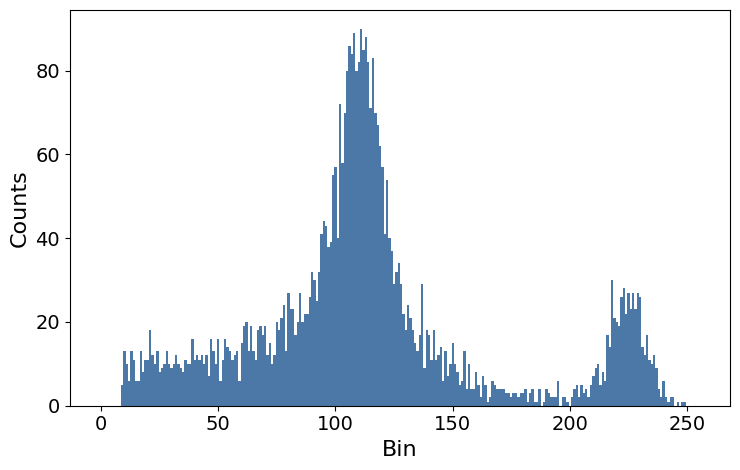

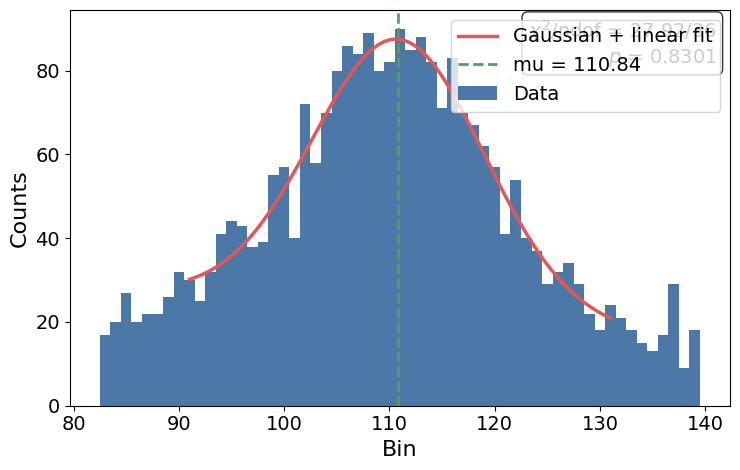

03-12-Cs137-scatter-50.Spe | detector=scatter | angle=50.0 deg | theta_eff=50.0 deg
selected candidate index = 4


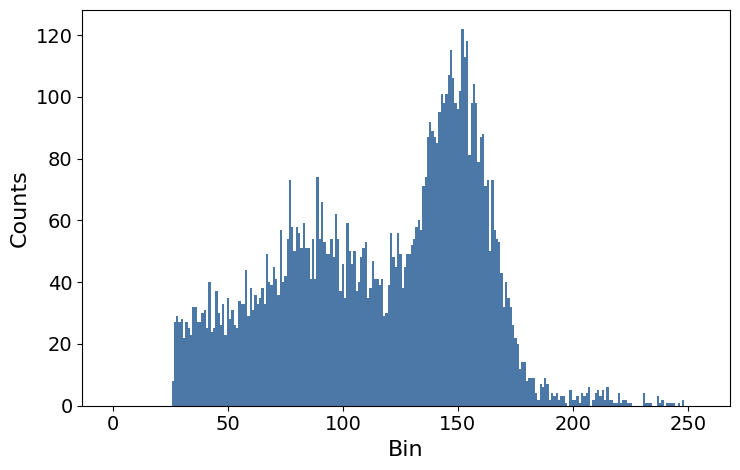

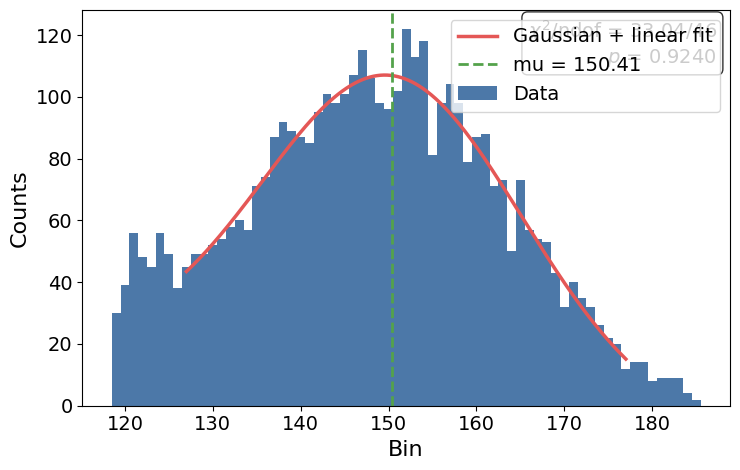

03-12-Cs137-scatter-80.Spe | detector=scatter | angle=80.0 deg | theta_eff=80.0 deg
selected candidate index = 2


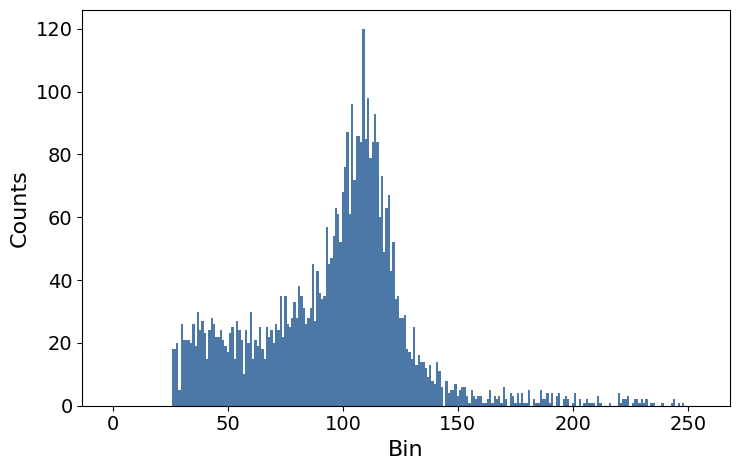

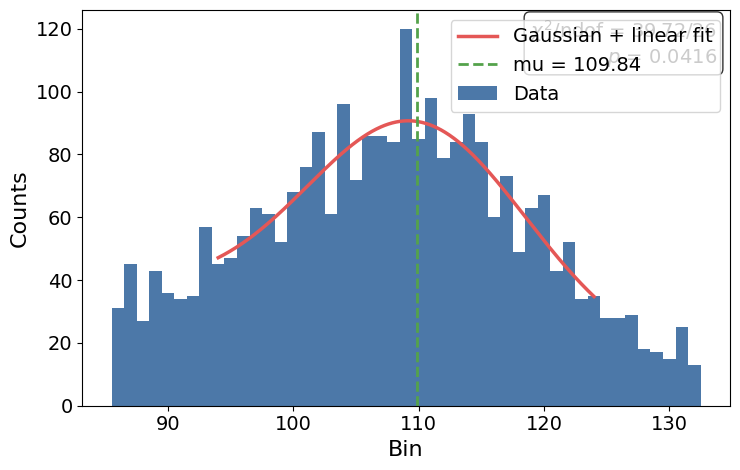

Computed results for 18 files
scatter files: 9
recoil files:  9

Fit quality summary (all analyzed files):
03-12-Cs137-recoil-50.Spe: chi2/ndof = 36.28/46, p = 0.8470
03-12-Cs137-recoil-80.Spe: chi2/ndof = 27.92/36, p = 0.8301
03-10-Cs137-Recoil-205.Spe: chi2/ndof = 31.50/36, p = 0.6824
03-10-Cs137-Recoil-210.Spe: chi2/ndof = 41.53/36, p = 0.2423
03-10-Cs137-Recoil-215.Spe: chi2/ndof = 35.80/36, p = 0.4782
03-10-Cs137-Recoil-220.Spe: chi2/ndof = 36.82/36, p = 0.4307
03-10-Cs137-Recoil-225.Spe: chi2/ndof = 45.60/36, p = 0.1312
03-10-Cs137-Recoil-250.Spe: chi2/ndof = 32.24/36, p = 0.6480
03-05-Cs137-recoil-280.Spe: chi2/ndof = 33.28/36, p = 0.5985
03-12-Cs137-scatter-50.Spe: chi2/ndof = 33.04/46, p = 0.9240
03-12-Cs137-scatter-80.Spe: chi2/ndof = 39.72/26, p = 0.0416
03-10-Cs137-Scatter-205.Spe: chi2/ndof = 44.98/26, p = 0.0118
03-10-Cs137-Scatter-210.Spe: chi2/ndof = 30.62/26, p = 0.2426
03-10-Cs137-Scatter-215.Spe: chi2/ndof = 24.41/26, p = 0.5524
03-10-Cs137-Scatter-220.Spe: chi2/ndof

In [115]:
# Run analysis for all angular files and keep results in notebook memory
# show_plots=True so you can inspect each file and choose/update peak_index_map.
# 310-deg runs are skipped at analysis stage (mapping still includes all files).

# Set of filenames for which to reduce fit_half_width to 15 or 10
_halfwidth_15_files_1 = {
    "03-12-Cs137-scatter-80.Spe",
    "03-10-Cs137-Scatter-205.Spe",
}
_halfwidth_15_files = {
    "03-10-Cs137-Scatter-210.Spe",
    "03-10-Cs137-Scatter-215.Spe",
}

angular_results = []
for fn in cs137_angular_files:
    try:
        meta = parse_cs137_angular_filename(fn)
        if np.isclose(meta["angle_deg"], 310.0):
            print(f"[SKIP] {fn} (angle = 310 deg)")
            continue

        # Set fit_half_width logic including exceptions
        if fn in _halfwidth_15_files_1:
            half_width = 15
        elif fn in _halfwidth_15_files:
            half_width = 15
        elif np.isclose(meta["angle_deg"], 50.0):
            half_width = 25
        else:
            half_width = 20

        r = analyze_angular_file(
            fn,
            peak_index_map=peak_index_map,
            show_plots=True,
            fit_half_width=half_width,
        )
        angular_results.append(r)
    except Exception as e:
        print(f"[WARN] {fn}: {e}")

print(f"Computed results for {len(angular_results)} files")

# Convenience split by detector type
angular_results_scatter = [r for r in angular_results if r["detector_type"] == "scatter"]
angular_results_recoil = [r for r in angular_results if r["detector_type"] == "recoil"]

print(f"scatter files: {len(angular_results_scatter)}")
print(f"recoil files:  {len(angular_results_recoil)}")

print("\nFit quality summary (all analyzed files):")
for r in sorted(angular_results, key=lambda z: (z["detector_type"], z["angle_deg"])):
    print(
        f"{r['filename']}: chi2/ndof = {r['chi2']:.2f}/{r['ndof']}, "
        f"p = {r['p_value']:.4f}"
    )

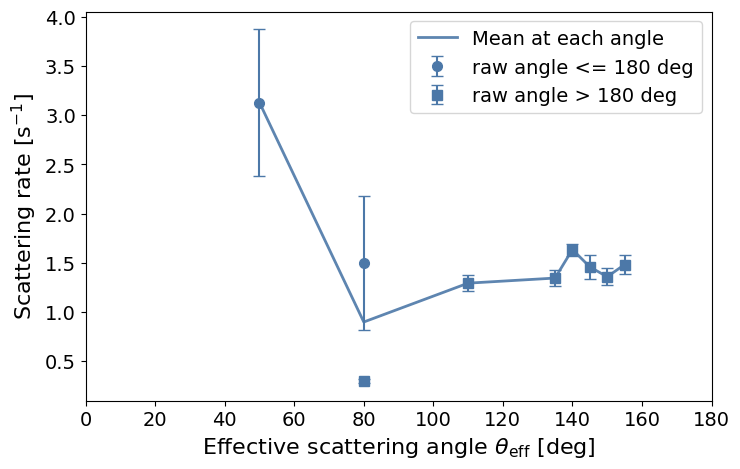

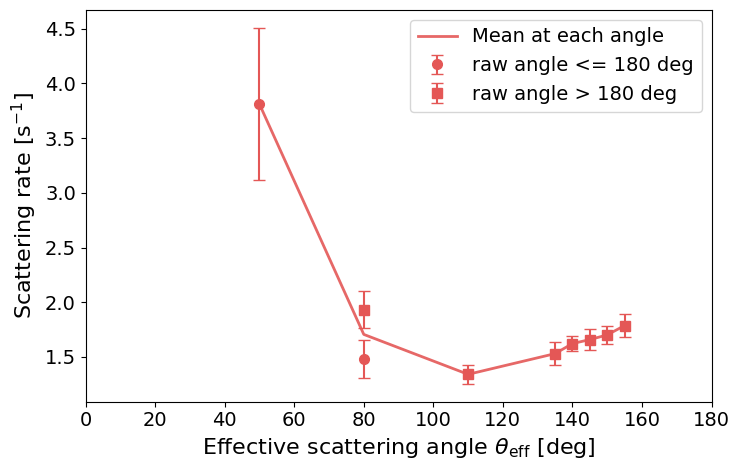

In [116]:
# Plot scattering rate vs effective scattering angle separately for each detector.
# - Individual datapoints are NOT connected.
# - Marker shape shows whether raw angle was <=180 or >180.
# - A separate line connects the mean rate at each effective angle.

def _extract_sorted_group(results_group):
    if len(results_group) == 0:
        return np.array([]), np.array([]), np.array([]), np.array([]), []
    x = np.array([r["theta_eff_deg"] for r in results_group], dtype=float)
    y = np.array([r["rate_cps"] for r in results_group], dtype=float)
    yerr = np.array([r["rate_err_cps"] for r in results_group], dtype=float)
    raw_angle = np.array([r["angle_deg"] for r in results_group], dtype=float)
    names = [r["filename"] for r in results_group]
    order = np.argsort(x)
    names_sorted = [names[i] for i in order]
    return x[order], y[order], yerr[order], raw_angle[order], names_sorted


def _plot_detector(results_group, color, detector_label):
    x, y, yerr, raw_angle, names = _extract_sorted_group(results_group)
    if len(x) == 0:
        return

    plt.figure()

    # Split points by original angle side relative to 180 deg.
    mask_le180 = raw_angle <= 180.0
    mask_gt180 = raw_angle > 180.0

    if np.any(mask_le180):
        plt.errorbar(
            x[mask_le180],
            y[mask_le180],
            yerr=yerr[mask_le180],
            fmt="o",
            color=color,
            ecolor=color,
            capsize=4,
            ms=7,
            linestyle="none",
            label=f"raw angle <= 180 deg",
        )

    if np.any(mask_gt180):
        plt.errorbar(
            x[mask_gt180],
            y[mask_gt180],
            yerr=yerr[mask_gt180],
            fmt="s",
            color=color,
            ecolor=color,
            capsize=4,
            ms=7,
            linestyle="none",
            label=f"raw angle > 180 deg",
        )

    # Mean-at-angle line (fixes odd visual jumps when two sides fold to same theta_eff).
    unique_x = np.unique(x)
    mean_y = np.array([np.mean(y[np.isclose(x, xx)]) for xx in unique_x], dtype=float)
    plt.plot(unique_x, mean_y, "-", color=color, lw=2.0, alpha=0.9, label="Mean at each angle")

    plt.xlabel(r"Effective scattering angle $\theta_{\mathrm{eff}}$ [deg]")
    plt.ylabel("Scattering rate [s$^{-1}$]")
    plt.xlim(0, 180)
    plt.legend()
    plt.tight_layout()
    plt.show()


_plot_detector(angular_results_scatter, color="#4C78A8", detector_label="Scatter detector")
_plot_detector(angular_results_recoil, color="#E45756", detector_label="Recoil detector")

## Theory scaling fits (Klein-Nishina and Thomson)

This section:
- consolidates duplicate effective angles using weighted means,
- fits a single scale factor to each theory curve via chi-square minimization,
- reports chi-square/ndof and p-value for each detector and model,
- and plots scatter/recoil data against both scaled theory curves.

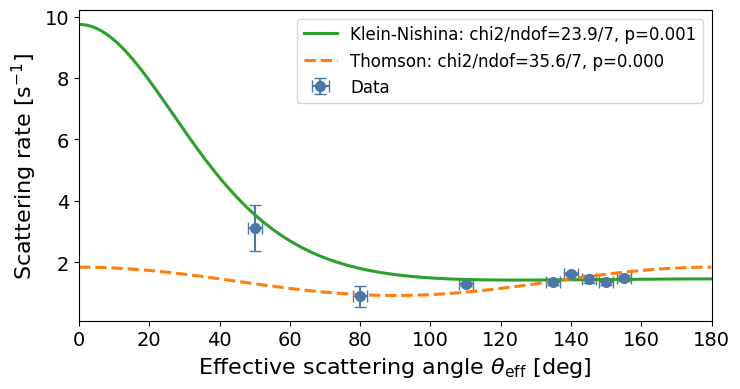


Scatter detector fit results (including ±2 deg angle uncertainty):
  Klein-Nishina: A = 1.227013e+26, chi2/ndof = 23.95/7, p = 0.0012
  Thomson:      A = 2.322703e+25, chi2/ndof = 35.57/7, p = 0.0000


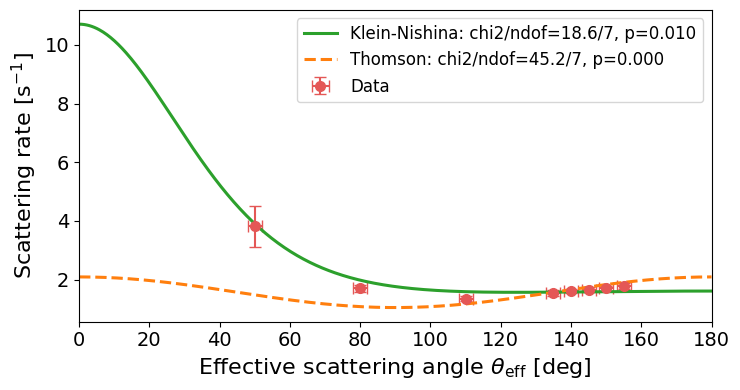


Recoil detector fit results (including ±2 deg angle uncertainty):
  Klein-Nishina: A = 1.348135e+26, chi2/ndof = 18.55/7, p = 0.0097
  Thomson:      A = 2.630668e+25, chi2/ndof = 45.24/7, p = 0.0000


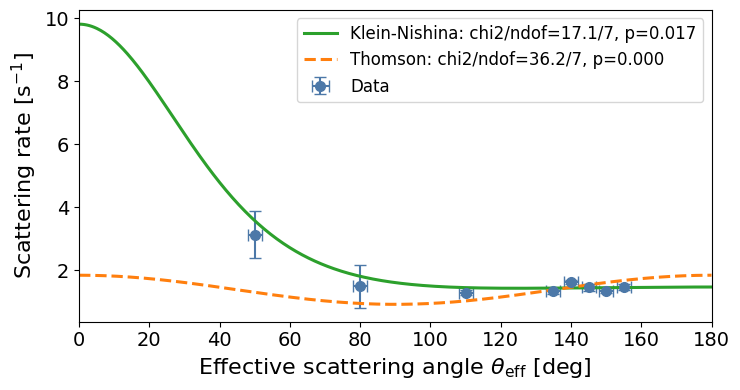


Scatter detector (excluding dial angle 280 deg) fit results (including ±2 deg angle uncertainty):
  Klein-Nishina: A = 1.235165e+26, chi2/ndof = 17.14/7, p = 0.0165
  Thomson:      A = 2.324889e+25, chi2/ndof = 36.20/7, p = 0.0000


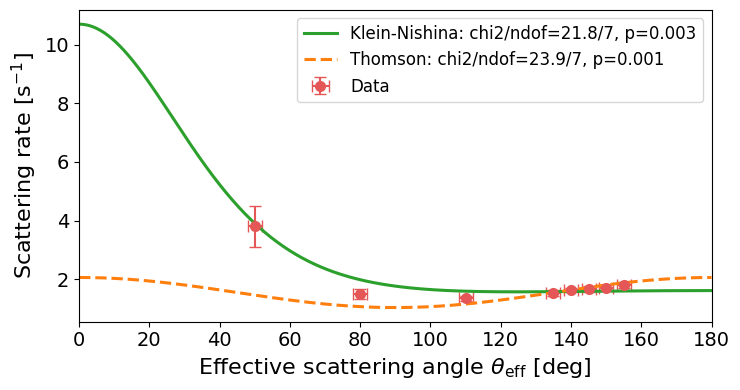


Recoil detector (excluding dial angle 280 deg) fit results (including ±2 deg angle uncertainty):
  Klein-Nishina: A = 1.348436e+26, chi2/ndof = 21.78/7, p = 0.0028
  Thomson:      A = 2.588020e+25, chi2/ndof = 23.87/7, p = 0.0012

Chi-square summaries:
Scatter vs Klein-Nishina: chi2/ndof = 23.95/7, p = 0.0012
Scatter vs Thomson:      chi2/ndof = 35.57/7, p = 0.0000
Recoil vs Klein-Nishina: chi2/ndof = 18.55/7, p = 0.0097
Recoil vs Thomson:      chi2/ndof = 45.24/7, p = 0.0000
Scatter (no 280) vs Klein-Nishina: chi2/ndof = 17.14/7, p = 0.0165
Scatter (no 280) vs Thomson:      chi2/ndof = 36.20/7, p = 0.0000
Recoil (no 280) vs Klein-Nishina: chi2/ndof = 21.78/7, p = 0.0028
Recoil (no 280) vs Thomson:      chi2/ndof = 23.87/7, p = 0.0012


In [121]:
from scipy.optimize import minimize_scalar
from scipy.stats import chi2 as chi2_dist

# --- constants and theory functions (from theory_comparison.py) ---
E0_KEV = 661.6
ME_KEV = 511.0
EPSILON = E0_KEV / ME_KEV
R_E_CM = 2.8179e-13
THETA_ERR_DEG = 2.0


def scattered_energy(theta_rad):
    return E0_KEV / (1.0 + EPSILON * (1.0 - np.cos(theta_rad)))


def dsigma_thomson(theta_rad):
    return 0.5 * R_E_CM**2 * (1.0 + np.cos(theta_rad) ** 2)


def dsigma_klein_nishina(theta_rad):
    ratio = scattered_energy(theta_rad) / E0_KEV
    return 0.5 * R_E_CM**2 * ratio**2 * (ratio + 1.0 / ratio - np.sin(theta_rad) ** 2)


def consolidate_by_effective_angle(results_group):
    """Simple-average duplicate theta_eff points (e.g., fold-over at 80 deg)."""
    if len(results_group) == 0:
        return np.array([]), np.array([]), np.array([])

    x = np.array([r["theta_eff_deg"] for r in results_group], dtype=float)
    y = np.array([r["rate_cps"] for r in results_group], dtype=float)
    yerr = np.array([r["rate_err_cps"] for r in results_group], dtype=float)

    out_x, out_y, out_err = [], [], []
    for xx in np.unique(x):
        m = np.isclose(x, xx)
        yi = y[m]
        ei = yerr[m]

        good = np.isfinite(yi) & np.isfinite(ei) & (ei > 0)
        yi = yi[good]
        ei = ei[good]
        if len(yi) == 0:
            continue

        ybar = np.mean(yi)
        # Standard error of the mean
        ebar = np.sqrt(np.sum(ei**2)) / len(ei)

        out_x.append(xx)
        out_y.append(ybar)
        out_err.append(ebar)

    out_x = np.array(out_x, dtype=float)
    out_y = np.array(out_y, dtype=float)
    out_err = np.array(out_err, dtype=float)

    order = np.argsort(out_x)
    return out_x[order], out_y[order], out_err[order]


def _dtheory_dtheta(theta_rad, theory_func):
    # Numerical derivative d(sigma)/dtheta (theta in radians)
    h = np.deg2rad(0.1)
    theta_lo = np.clip(theta_rad - h, 0.0, np.pi)
    theta_hi = np.clip(theta_rad + h, 0.0, np.pi)
    denom = np.maximum(theta_hi - theta_lo, 1e-12)
    return (theory_func(theta_hi) - theory_func(theta_lo)) / denom


def _chi2_with_theta_unc(theta_deg, rates, rate_errs, theory_func, A, theta_err_deg):
    theta_rad = np.deg2rad(theta_deg)
    T = theory_func(theta_rad)
    model = A * T

    dT_dtheta = _dtheory_dtheta(theta_rad, theory_func)
    sigma_theta_term = np.abs(A * dT_dtheta * np.deg2rad(theta_err_deg))
    sigma_eff = np.sqrt(rate_errs**2 + sigma_theta_term**2)

    chi2_val = float(np.sum(((rates - model) / sigma_eff) ** 2))
    return chi2_val


def best_fit_scale(theta_deg, rates, rate_errs, theory_func, theta_err_deg=0.0):
    theta_rad = np.deg2rad(theta_deg)
    T = theory_func(theta_rad)
    w = 1.0 / rate_errs**2
    A0 = np.sum(w * rates * T) / np.sum(w * T**2)

    if theta_err_deg <= 0:
        return float(A0)

    # Refit A including angle uncertainty contribution in denominator.
    upper = max(10.0 * abs(A0), 1.0)
    res = minimize_scalar(
        lambda A: _chi2_with_theta_unc(theta_deg, rates, rate_errs, theory_func, A, theta_err_deg),
        bounds=(0.0, upper),
        method="bounded",
    )
    return float(res.x)


def chi2_stats(theta_deg, rates, rate_errs, theory_func, A, theta_err_deg=0.0):
    if theta_err_deg > 0:
        chi2_val = _chi2_with_theta_unc(theta_deg, rates, rate_errs, theory_func, A, theta_err_deg)
    else:
        theta_rad = np.deg2rad(theta_deg)
        model = A * theory_func(theta_rad)
        chi2_val = float(np.sum(((rates - model) / rate_errs) ** 2))

    ndof = int(len(rates) - 1)  # one fitted parameter (scale A)
    p_val = float(chi2_dist.sf(chi2_val, ndof)) if ndof > 0 else np.nan
    return chi2_val, ndof, p_val


def fit_and_plot_theory_scaling(results_group, detector_label, color, exclude_dial_angle=None):
    use_group = list(results_group)
    if exclude_dial_angle is not None:
        use_group = [r for r in use_group if not np.isclose(r["angle_deg"], float(exclude_dial_angle))]

    th_deg, rates, errs = consolidate_by_effective_angle(use_group)
    if len(th_deg) < 2:
        print(f"Not enough consolidated points for {detector_label}")
        return None

    A_kn = best_fit_scale(th_deg, rates, errs, dsigma_klein_nishina, theta_err_deg=THETA_ERR_DEG)
    A_th = best_fit_scale(th_deg, rates, errs, dsigma_thomson, theta_err_deg=THETA_ERR_DEG)

    chi2_kn, ndof_kn, p_kn = chi2_stats(
        th_deg, rates, errs, dsigma_klein_nishina, A_kn, theta_err_deg=THETA_ERR_DEG
    )
    chi2_th, ndof_th, p_th = chi2_stats(
        th_deg, rates, errs, dsigma_thomson, A_th, theta_err_deg=THETA_ERR_DEG
    )

    theta_fine_deg = np.linspace(0.0, 180.0, 500)
    theta_fine_rad = np.deg2rad(theta_fine_deg)

    subtitle = ""
    if exclude_dial_angle is not None:
        subtitle = f" (excluding dial angle {int(exclude_dial_angle)} deg)"

    plt.figure(figsize=(7.5, 4))
    plt.errorbar(
        th_deg,
        rates,
        xerr=THETA_ERR_DEG,
        yerr=errs,
        fmt="o",
        color=color,
        ecolor=color,
        capsize=4,
        ms=7,
        label="Data",
    )
    plt.plot(
        theta_fine_deg,
        A_kn * dsigma_klein_nishina(theta_fine_rad),
        color="#2ca02c",
        lw=2.2,
        label=f"Klein-Nishina: chi2/ndof={chi2_kn:.1f}/{ndof_kn}, p={p_kn:.3f}",
    )
    plt.plot(
        theta_fine_deg,
        A_th * dsigma_thomson(theta_fine_rad),
        color="#ff7f0e",
        lw=2.2,
        ls="--",
        label=f"Thomson: chi2/ndof={chi2_th:.1f}/{ndof_th}, p={p_th:.3f}",
    )

    plt.xlabel(r"Effective scattering angle $\theta_{\mathrm{eff}}$ [deg]")
    plt.ylabel("Scattering rate [s$^{-1}$]")
    plt.xlim(0, 180)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()

    print(f"\n{detector_label} detector{subtitle} fit results (including ±{THETA_ERR_DEG:.0f} deg angle uncertainty):")
    print(
        f"  Klein-Nishina: A = {A_kn:.6e}, "
        f"chi2/ndof = {chi2_kn:.2f}/{ndof_kn}, p = {p_kn:.4f}"
    )
    print(
        f"  Thomson:      A = {A_th:.6e}, "
        f"chi2/ndof = {chi2_th:.2f}/{ndof_th}, p = {p_th:.4f}"
    )

    return {
        "detector": detector_label,
        "exclude_dial_angle": exclude_dial_angle,
        "A_kn": A_kn,
        "chi2_kn": chi2_kn,
        "ndof_kn": ndof_kn,
        "p_kn": p_kn,
        "A_th": A_th,
        "chi2_th": chi2_th,
        "ndof_th": ndof_th,
        "p_th": p_th,
    }


# Full datasets
fit_summary_scatter = fit_and_plot_theory_scaling(
    angular_results_scatter,
    detector_label="Scatter",
    color="#4C78A8",
)
fit_summary_recoil = fit_and_plot_theory_scaling(
    angular_results_recoil,
    detector_label="Recoil",
    color="#E45756",
)

# Excluding dial angle 280-deg outliers
fit_summary_scatter_no280 = fit_and_plot_theory_scaling(
    angular_results_scatter,
    detector_label="Scatter",
    color="#4C78A8",
    exclude_dial_angle=280,
)
fit_summary_recoil_no280 = fit_and_plot_theory_scaling(
    angular_results_recoil,
    detector_label="Recoil",
    color="#E45756",
    exclude_dial_angle=280,
)

print("\nChi-square summaries:")
def _print_pair(tag, summary):
    if summary is None:
        return
    print(
        f"{tag} vs Klein-Nishina: chi2/ndof = "
        f"{summary['chi2_kn']:.2f}/{summary['ndof_kn']}, p = {summary['p_kn']:.4f}"
    )
    print(
        f"{tag} vs Thomson:      chi2/ndof = "
        f"{summary['chi2_th']:.2f}/{summary['ndof_th']}, p = {summary['p_th']:.4f}"
    )

_print_pair("Scatter", fit_summary_scatter)
_print_pair("Recoil", fit_summary_recoil)
_print_pair("Scatter (no 280)", fit_summary_scatter_no280)
_print_pair("Recoil (no 280)", fit_summary_recoil_no280)